# Idea

Get more insight into the active features, lags and coefficients.

## Naming Conventions with example:

Belong to X:
- Feature: *|avg B|* (refers to a measured physical parameter)
- Lag: *|avg B|_lag_1* (refers to all columns in X)

Belong to y:
- Target: *y_step_1*

Belong to the Model:
- Coefficient: each coefficient belongs to one Lag and a target

In [1]:
import os
# os.nice(19)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
start_time = '2024-07-24 00:00:00'
end_time = '2024-12-31 12:59:00'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
GFOC_data = GFOC_data.loc[start_time:end_time]
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X_test = pd.read_parquet(X_file)
X_test = X_test.loc[start_time:end_time]
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y_test = pd.read_parquet(y_file)
y_test = y_test.loc[start_time:end_time]
print(f"✅ Successfully loaded features X_test with shape: {X_test.shape} and target y_test with shape: {y_test.shape}")

✅ Successfully loaded data with shape: (46236, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X_test with shape: (46224, 538) and target y_test with shape: (46224, 48)


# Load Models

In [4]:
from pathlib import Path
import re
import joblib

MODEL_DIR = find_repo_root() / Path("Analysis/modeling/tscv_models")

pipelines = {}

# pattern:
# tscv_MultiTaskLasso_{target}_pipeline_{alpha}_{number}.pkl
pattern = re.compile(
    r'tscv_MultiTaskLasso_'
    r'(?P<target>.+?)_pipeline_'
    r'(?P<alpha>\d+p\d+)_'
    r'(?P<number>[A-Za-z0-9]+)\.pkl'
)

# --- collect and sort files deterministically ---
pkl_files = []

for pkl_file in MODEL_DIR.glob("*.pkl"):
    match = pattern.match(pkl_file.name)
    if not match:
        continue

    target = match.group("target")
    alpha = float(match.group("alpha").replace("p", "."))
    number = match.group("number")  # string, e.g. "1", "1i"

    pkl_files.append((target, number, alpha, pkl_file))

# sort by target, number, alpha
pkl_files.sort(key=lambda x: (x[0], x[1], x[2]))

# --- load pipelines ---
for target, number, alpha, pkl_file in pkl_files:
    pipelines.setdefault(target, {}).setdefault(number, {})[alpha] = (
joblib.load(pkl_file)
    )

print(f"✅ Successfully loaded pipelines for targets: {list(pipelines.keys())}")

✅ Successfully loaded pipelines for targets: ['trend']


Remove unwanted pipelines (depend on the sampling rate)

In [5]:
# remove pipeline with number '14' if exists
if '14' in pipelines.get(target, {}):
    del pipelines[target]['14']
    print("Removed pipeline with number '14' due to known issues.")

Removed pipeline with number '14' due to known issues.


Show all loaded pipelines

In [6]:
for target in pipelines.keys():
    print(f"Target: {target}")
    for number in pipelines[target].keys():
        alphas = list(pipelines[target][number].keys())
        print(f"  Number: {number}, Alphas: {alphas}")

Target: trend
  Number: 1, Alphas: [0.05, 0.075, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0]
  Number: 1i, Alphas: [0.05, 0.1]
  Number: 3, Alphas: [0.05, 0.1, 0.25, 0.5, 1.0, 5.0]
  Number: 4, Alphas: [0.02, 0.05, 0.1, 0.5, 1.0, 5.0]
  Number: 4i, Alphas: [0.1, 0.5]


# 1. Check Coefficients for one Pipeline

select pipeline

In [7]:
Alpha = 0.1
target = 'trend'
number = '3'

#
pipeline = pipelines[target][number][Alpha]
print(f"✅ Using pipeline for target '{target}', number '{number}', alpha {Alpha}")

✅ Using pipeline for target 'trend', number '3', alpha 0.1


In [8]:
coeff_all = pipeline.named_steps['lasso'].coef_

print("Coefficient array shape:", coeff_all.shape)
coeff_matrix = pd.DataFrame(
    coeff_all,
    index=y_test.columns,
    columns=X_test.columns
)
print("Coefficient matrix shape:", coeff_matrix.shape)

# Summary of active coefficients
active_coefs = np.sum(coeff_all != 0)
print(f"\nActive Coefficients: {active_coefs:3d}/{coeff_all.size} ({(active_coefs/coeff_all.size)*100:.2f}%)")

# Flatten coefficients and corresponding feature names
coef_values = coeff_all[coeff_all != 0]
coef_names = X_test.columns[np.where(coeff_all != 0)[1]]
coef_features = coef_names.str.extract(r'^(.+?)_lag_')[0]

df = pd.DataFrame({
    "feature": coef_features.values,
    "coef": coef_values
})

summary = (
    df.assign(
pos=lambda d: d["coef"] > 0,
        neg=lambda d: d["coef"] < 0
    )
    .groupby("feature")
    .agg(
        n_coefficients=("coef", "size"),
        pos=("pos", "sum"),
        neg=("neg", "sum")
    )
    .reset_index()
)

# percentage positive
summary["pct_pos"] = 100 * summary["pos"] / summary["n_coefficients"]

# print
for row in summary.itertuples(index=False):
    print(
        f'   {row.feature:25}: {row.n_coefficients:4} coefficients '
        f'(positive: {row.pos:4} = {row.pct_pos:.1f}%, negative: {row.neg:4} = {100-row.pct_pos:.1f}%)'
    )


Coefficient array shape: (48, 538)
Coefficient matrix shape: (48, 538)

Active Coefficients: 18192/25824 (70.45%)
   Bz GSE                   : 6096 coefficients (positive: 3205 = 52.6%, negative: 2891 = 47.4%)
   F10.7 (LASP)             :  336 coefficients (positive:  272 = 81.0%, negative:   64 = 19.0%)
   Flow Speed (km/s         : 3168 coefficients (positive: 1187 = 37.5%, negative: 1981 = 62.5%)
   Temperature (K)          : 3264 coefficients (positive: 1135 = 34.8%, negative: 2129 = 65.2%)
   median_decay_last_14D    :   96 coefficients (positive:   48 = 50.0%, negative:   48 = 50.0%)
   median_decay_last_30D    :  144 coefficients (positive:   48 = 33.3%, negative:   96 = 66.7%)
   median_decay_last_7D     :  144 coefficients (positive:   48 = 33.3%, negative:   96 = 66.7%)
   |avg B|                  : 4944 coefficients (positive: 1976 = 40.0%, negative: 2968 = 60.0%)


## 1.1 Coef Matrix

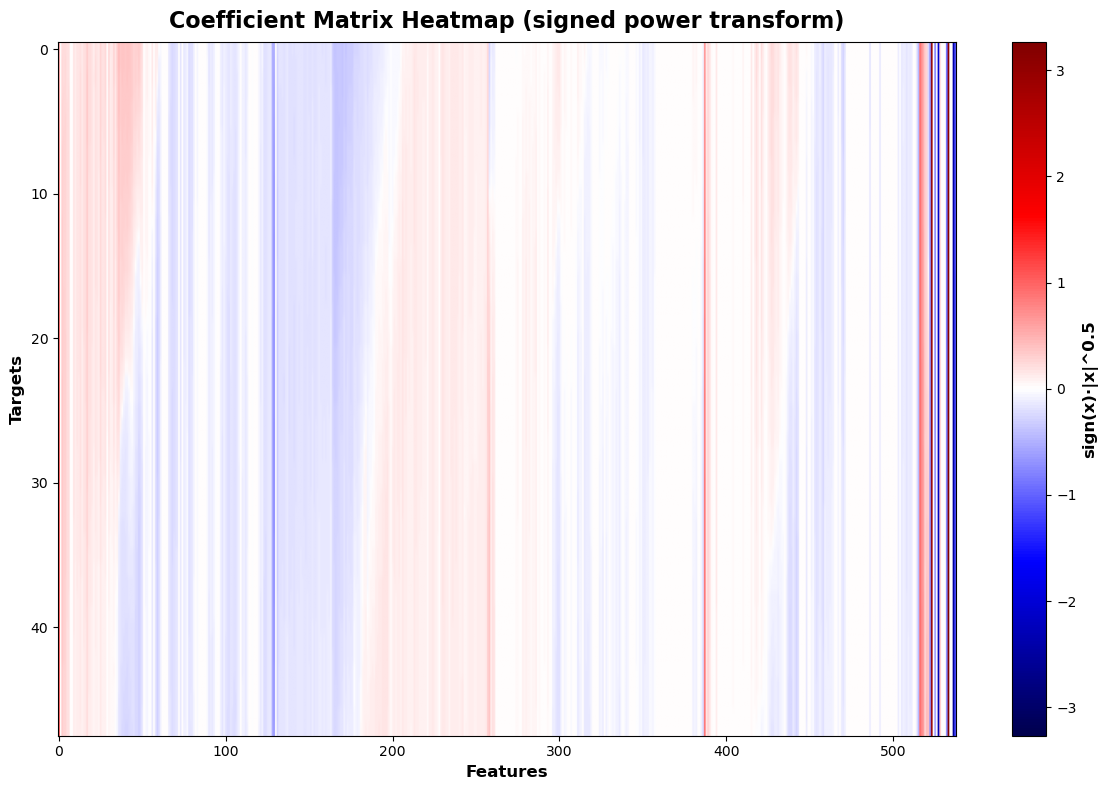

In [9]:
coeff_transformed = np.sign(coeff_matrix) * np.abs(coeff_matrix) ** 0.5

plt.figure(figsize=(12, 8))
plt.imshow(
    coeff_transformed,
    aspect='auto',
    cmap='seismic',
    vmin=-np.max(np.abs(coeff_transformed.values)),
    vmax=np.max(np.abs(coeff_transformed.values))
)
plt.colorbar(label=f'sign(x)·|x|^{alpha}')
plt.xlabel('Features')
plt.ylabel('Targets')
plt.title('Coefficient Matrix Heatmap (signed power transform)')
plt.show()

## 1.2 Coeff Matrix by Feature

In [10]:
coef_df = pd.DataFrame({
    'feature': X_test.columns,
    'coefficient_0': coeff_all[0, :],
    'coefficient_n': coeff_all[-1, :],
    'coefficient_mean': coeff_all.mean(axis=0),
    'coefficient_std': coeff_all.std(axis=0),
    'coefficient_max': coeff_all.max(axis=0),
    'coefficient_min': coeff_all.min(axis=0),
    'coefficient_absmax': np.max(np.abs(coeff_all), axis=0),
    'coefficient_range': coeff_all.max(axis=0) - coeff_all.min(axis=0),
})

stepsize = 5 / 60 # in hours
coef_df[["feature", "lag"]] = (
    coef_df["feature"]
    .str.extract(r"^(?P<feature_name>.+?)_lag_(?P<lag>\d+)$")
)
coef_df['lag_time'] = coef_df['lag'].astype(int) * stepsize

Feature: |avg B|


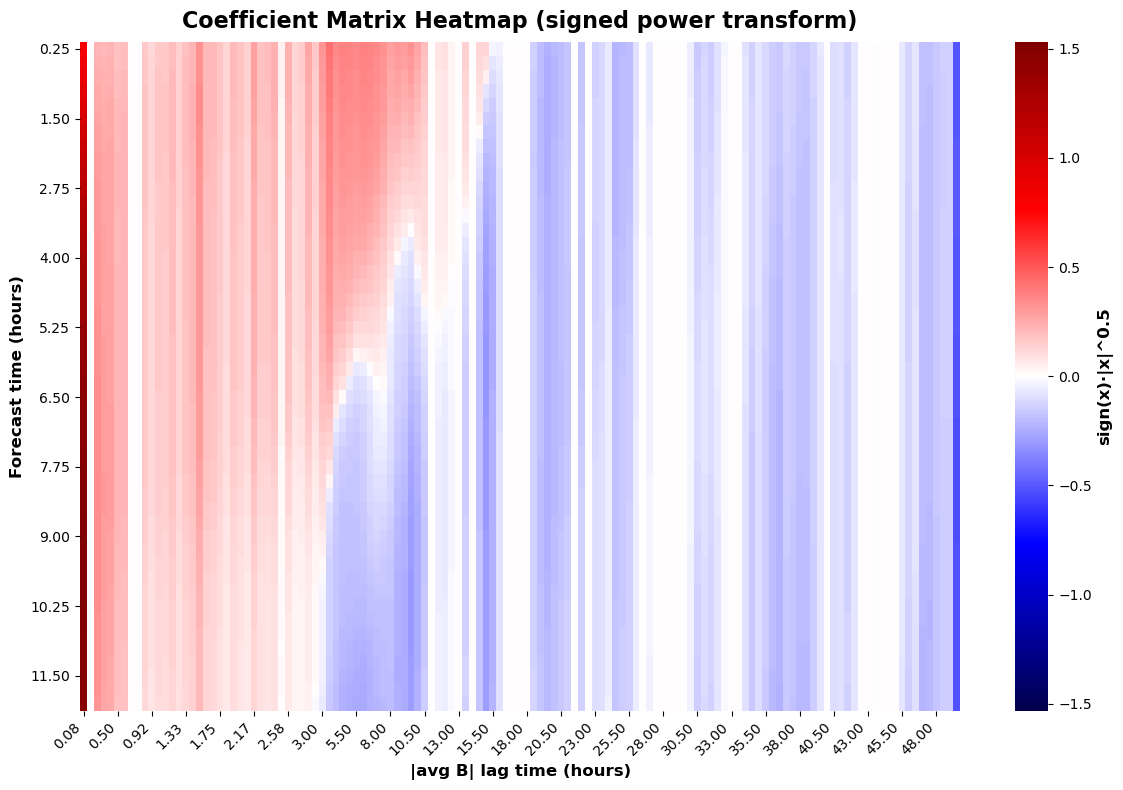

Feature: Bz GSE


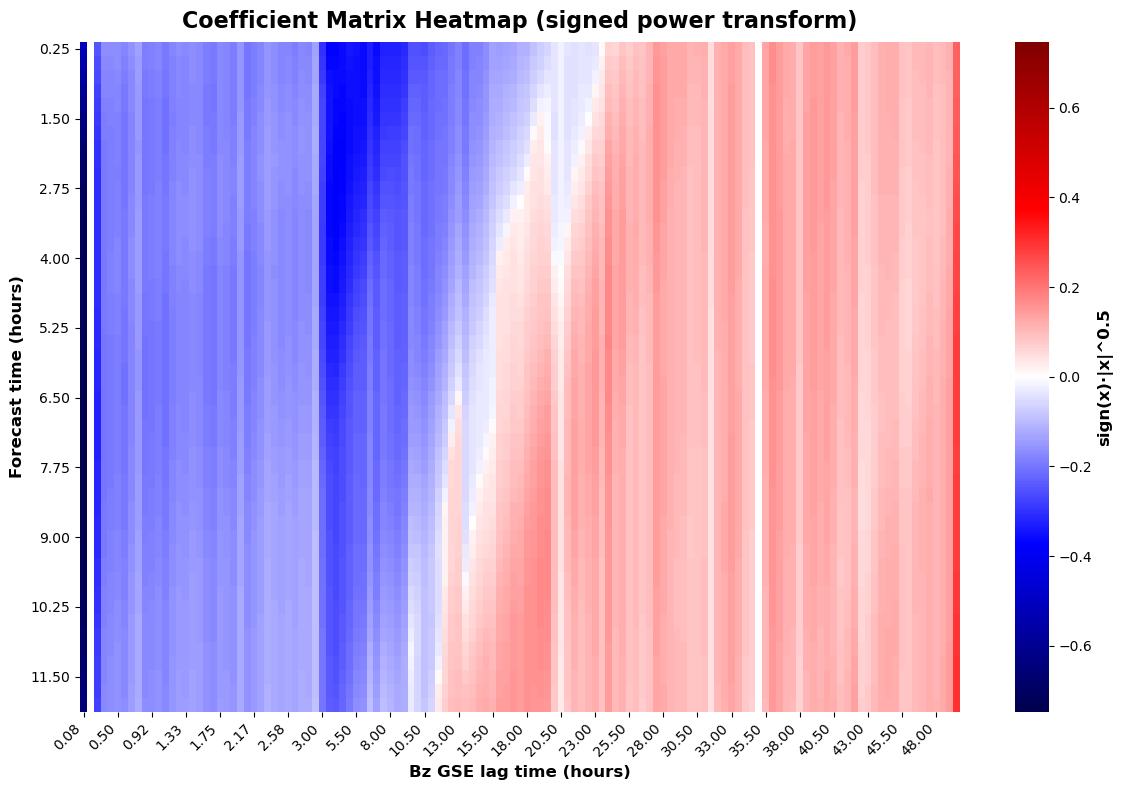

Feature: Temperature (K)


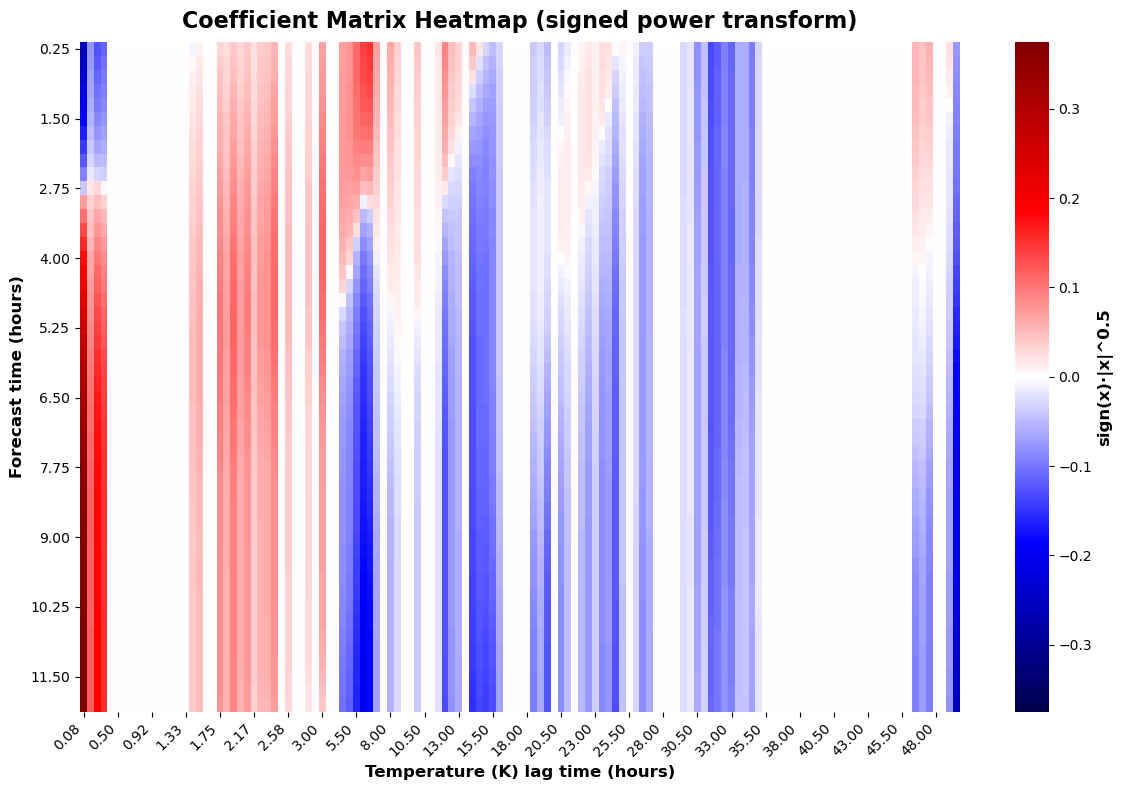

Feature: Flow Speed (km/s


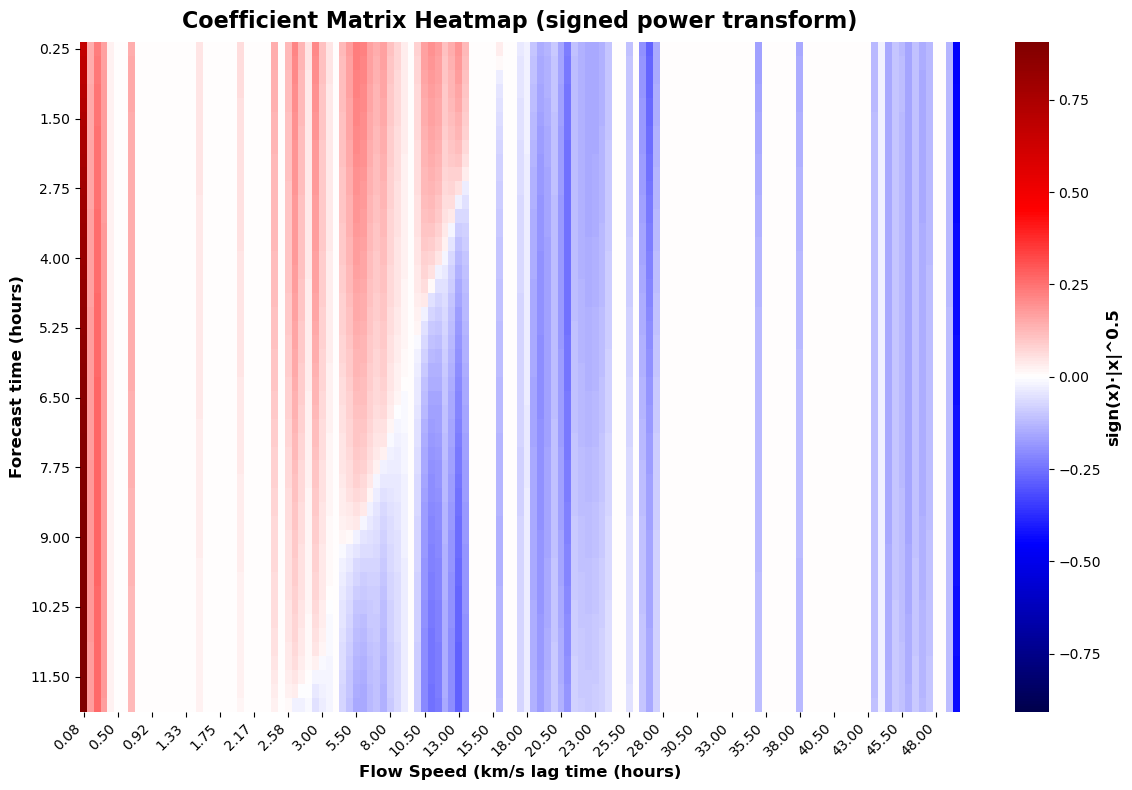

Feature: F10.7 (LASP)


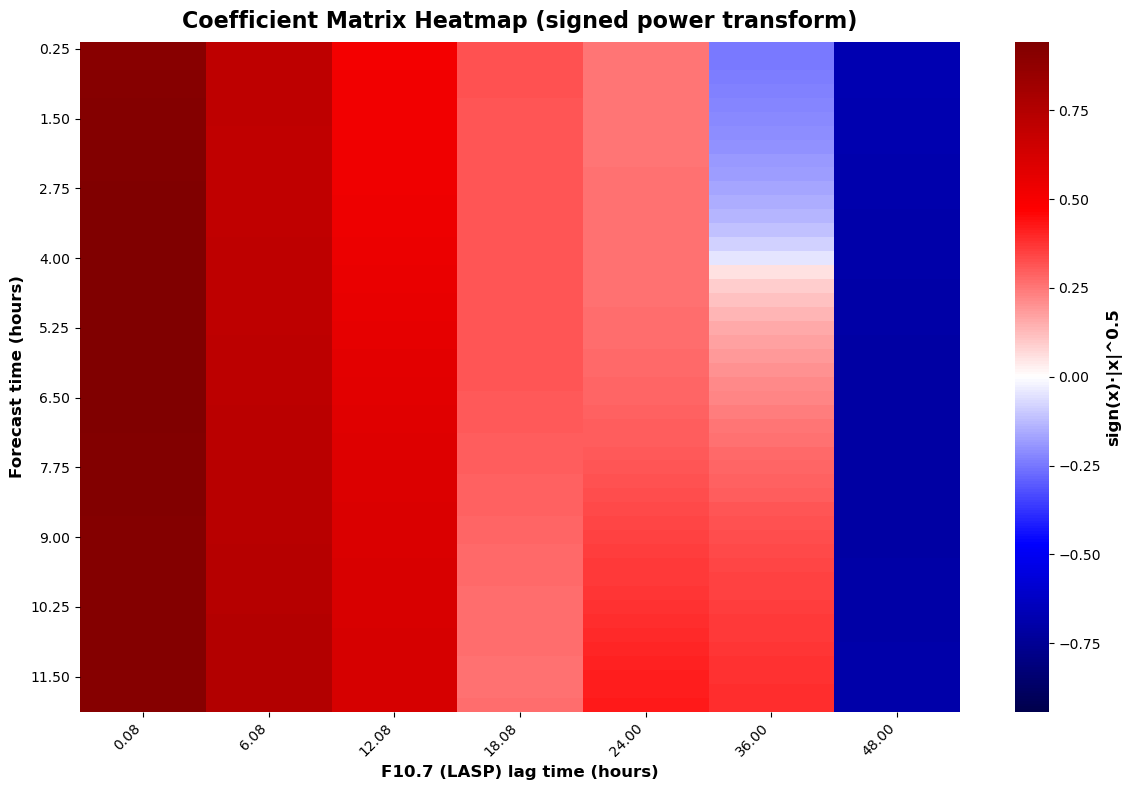

Feature: median_decay_last_7D


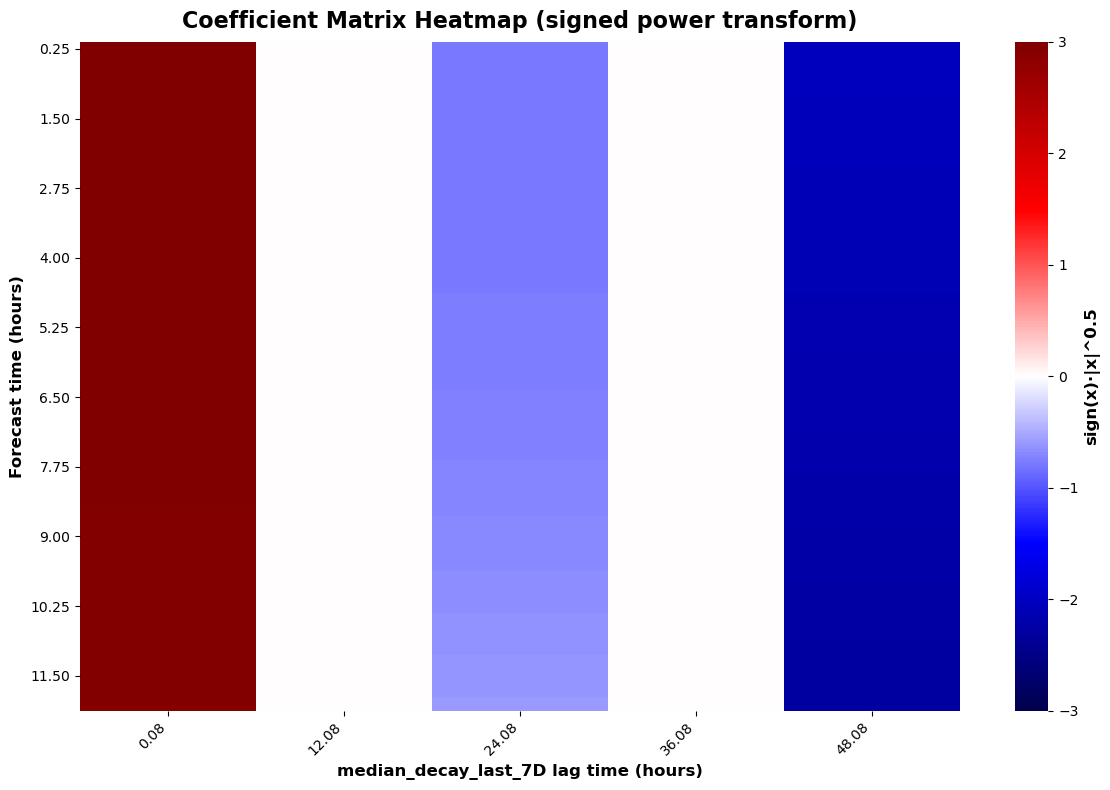

Feature: median_decay_last_14D


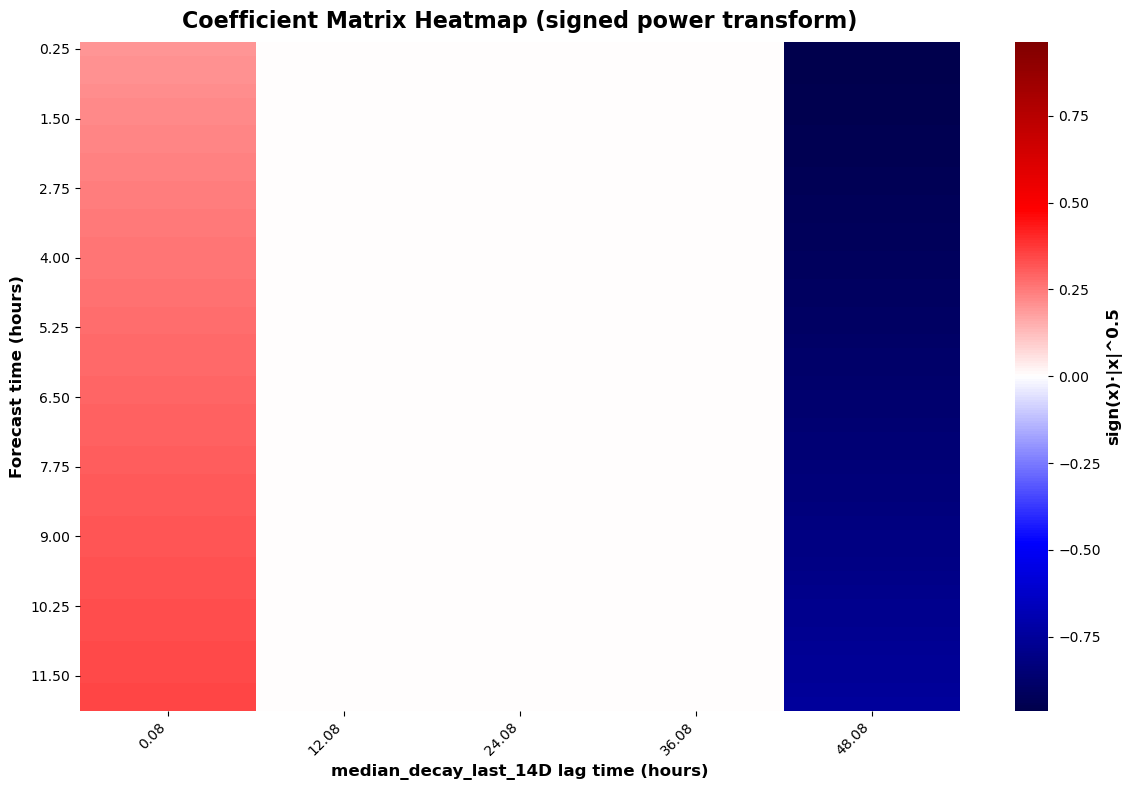

Feature: median_decay_last_30D


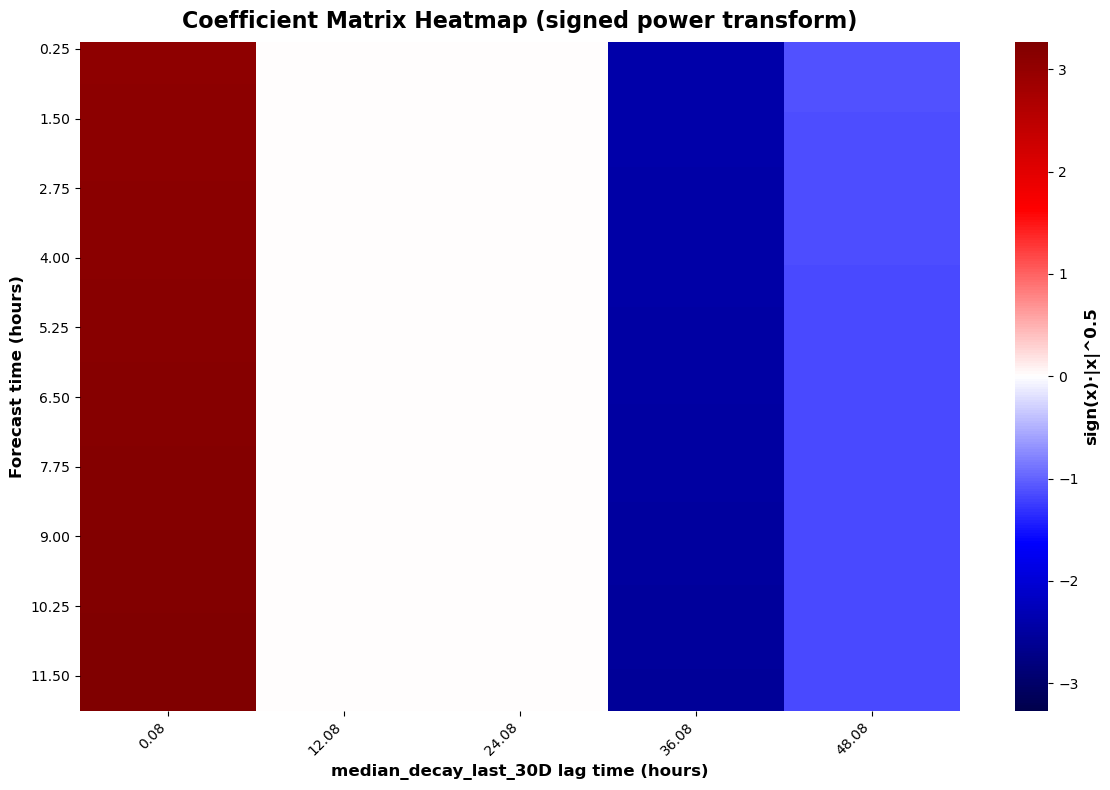

In [11]:
feature = '|avg B|' #'|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)'
unique_features = coef_df['feature'].unique()
for feature in unique_features:
    print(f"Feature: {feature}")
    # keep all columns with column name = feature_lag_{d}
    feature_cols = [col for col in X_test.columns if col.startswith(f"{feature}_lag_")]
    feature_cmatrix = coeff_matrix[feature_cols]

    feature_coefs = coef_df[coef_df['feature'] == feature]

    coeff_transformed = np.sign(feature_cmatrix) * np.abs(feature_cmatrix) ** 0.5

    if len(feature_cols) > 10:
        xstep = 5
    else:
        xstep = 1
    ystep = 5

    plt.figure(figsize=(12, 8))

    ax = sns.heatmap(
        coeff_transformed,
        cmap="seismic",
        center=0,
        vmin=-np.max(np.abs(coeff_transformed.values)),
        vmax=np.max(np.abs(coeff_transformed.values)),
        cbar_kws={"label": f"sign(x)·|x|^{alpha}"},
        xticklabels=False,  # turn off automatic labels
        yticklabels=False
    )

    # Select ticks every `step`
    x_ticks = np.arange(0, coeff_transformed.shape[1], xstep)
    y_ticks = np.arange(0, coeff_transformed.shape[0], ystep)

    ax.set_xticks(x_ticks + 0.5)  # +0.5 centers ticks in cells
    ax.set_yticks(y_ticks + 0.5)

    x_labels = [f"{feature_coefs['lag_time'].iloc[i]:.2f}" for i in x_ticks]
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    y_labels = [f"{0.25*(i+1):.2f}" for i in y_ticks]  # Assuming 0.25 hours step for targets
    # y_labels = [f"{coeff_transformed.index[i]:.2f}" for i in y_ticks]
    ax.set_yticklabels(y_labels, rotation=0)

    plt.xlabel(feature+" lag time (hours)")
    plt.ylabel("Forecast time (hours)")
    plt.title("Coefficient Matrix Heatmap (signed power transform)")
    plt.tight_layout()
    plt.show()

## 1.3 Plot coefficient stability

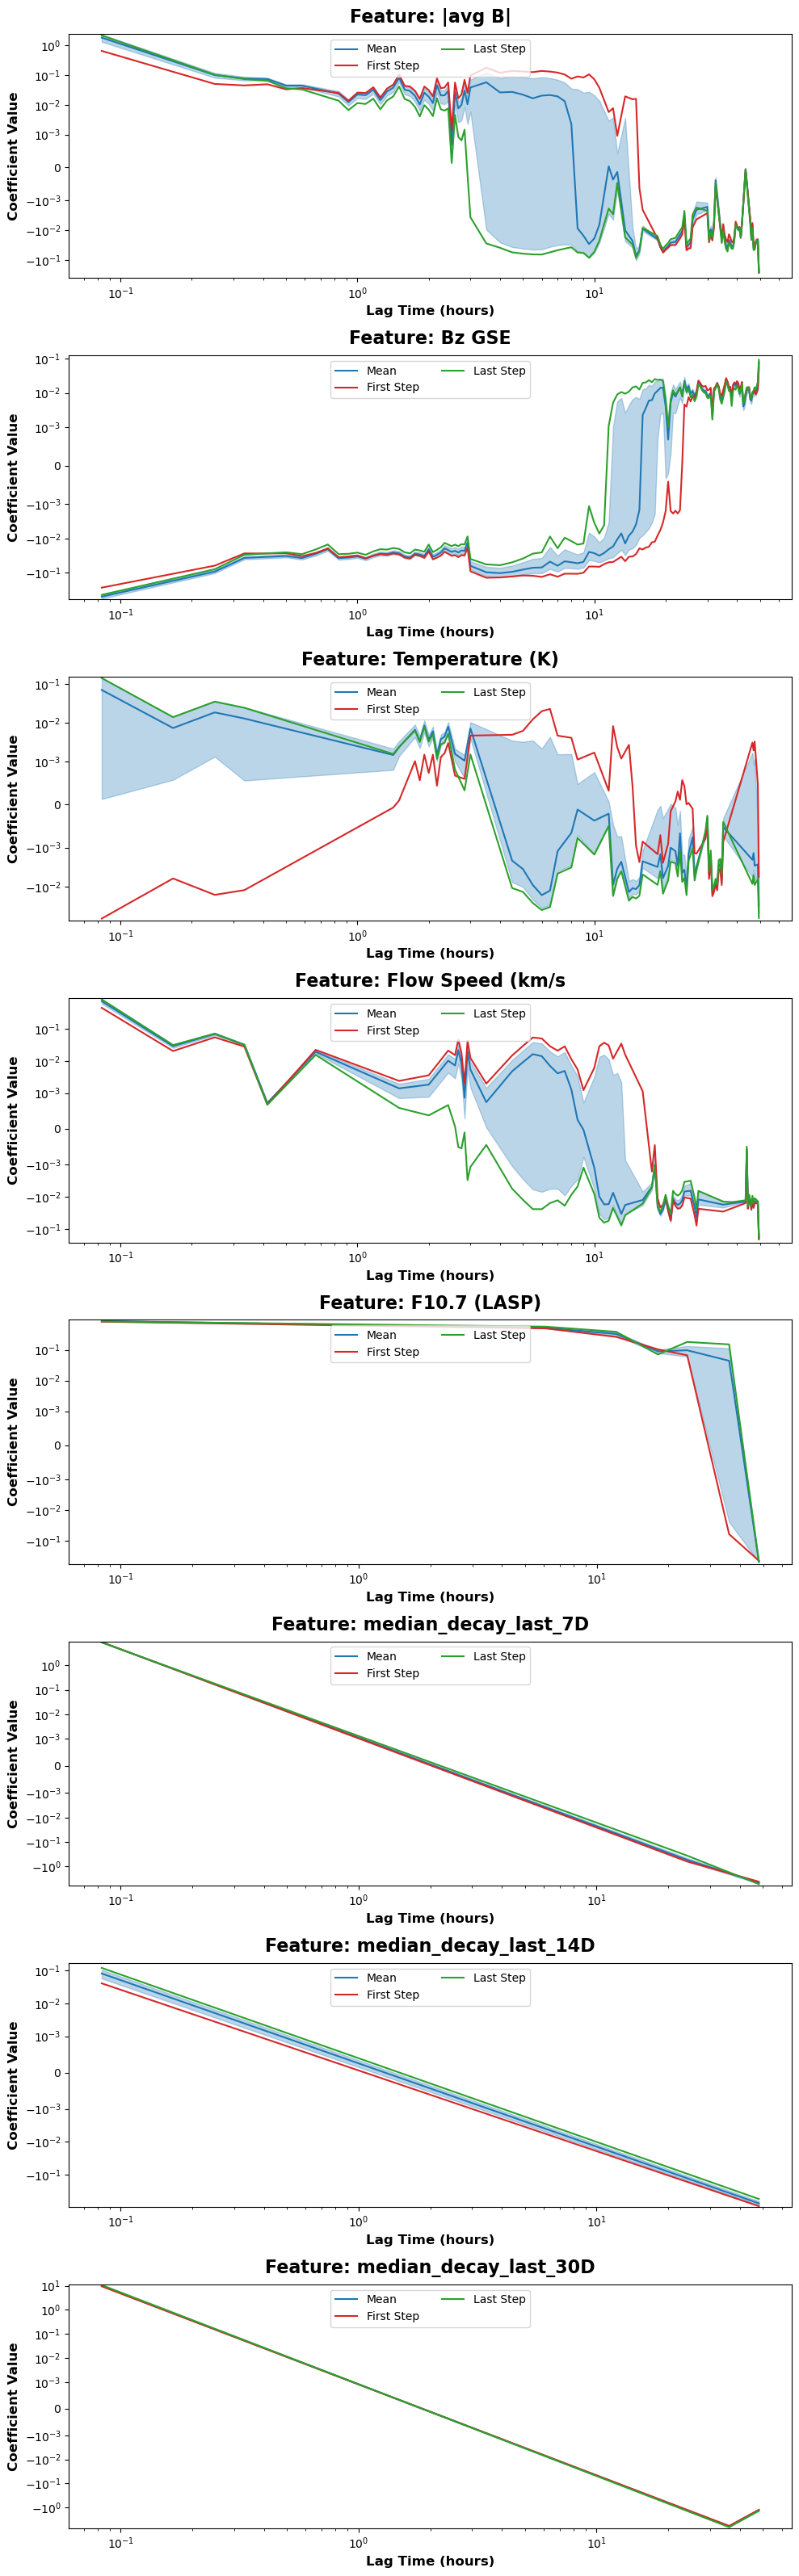

In [12]:
# unique features
unique_features = coef_df['feature'].unique()

fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    
    # only include coefficients where mean is bigger than 1e-3
    feature_coefs = feature_coefs[feature_coefs['coefficient_mean'].abs() > 1e-6]

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_mean'],
        color='tab:blue',
        ms=4,
        alpha = 1.0,
        label="Mean"
    )

    ax.fill_between(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_mean'] - feature_coefs['coefficient_std'],
        feature_coefs['coefficient_mean'] + feature_coefs['coefficient_std'],
        color='tab:blue',
        alpha=0.3,
    )

    # ax.plot(
    #     feature_coefs['lag_time'],
    #     feature_coefs['coefficient_max'],
    #     color='tab:red',
    #     ms=4,
    #     alpha = 1.0,
    #     label="Max"
    # )

    # ax.plot(
    #     feature_coefs['lag_time'],
    #     feature_coefs['coefficient_min'],
    #     color='tab:green',
    #     ms=4,
    #     alpha = 1.0,
    #     label="Min"
    # )

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_0'],
        color='tab:red',
        ms=4,
        alpha = 1.0,
        label="First Step"
    )

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_n'],
        color='tab:green',
        ms=4,
        alpha = 1.0,
        label="Last Step"
    )
    
    ax.set_title(f'Feature: {feature}')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_xscale('log')
    ax.set_yscale('symlog', linthresh=1e-3)  # Use symmetric log scale for better visibility of small values
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()

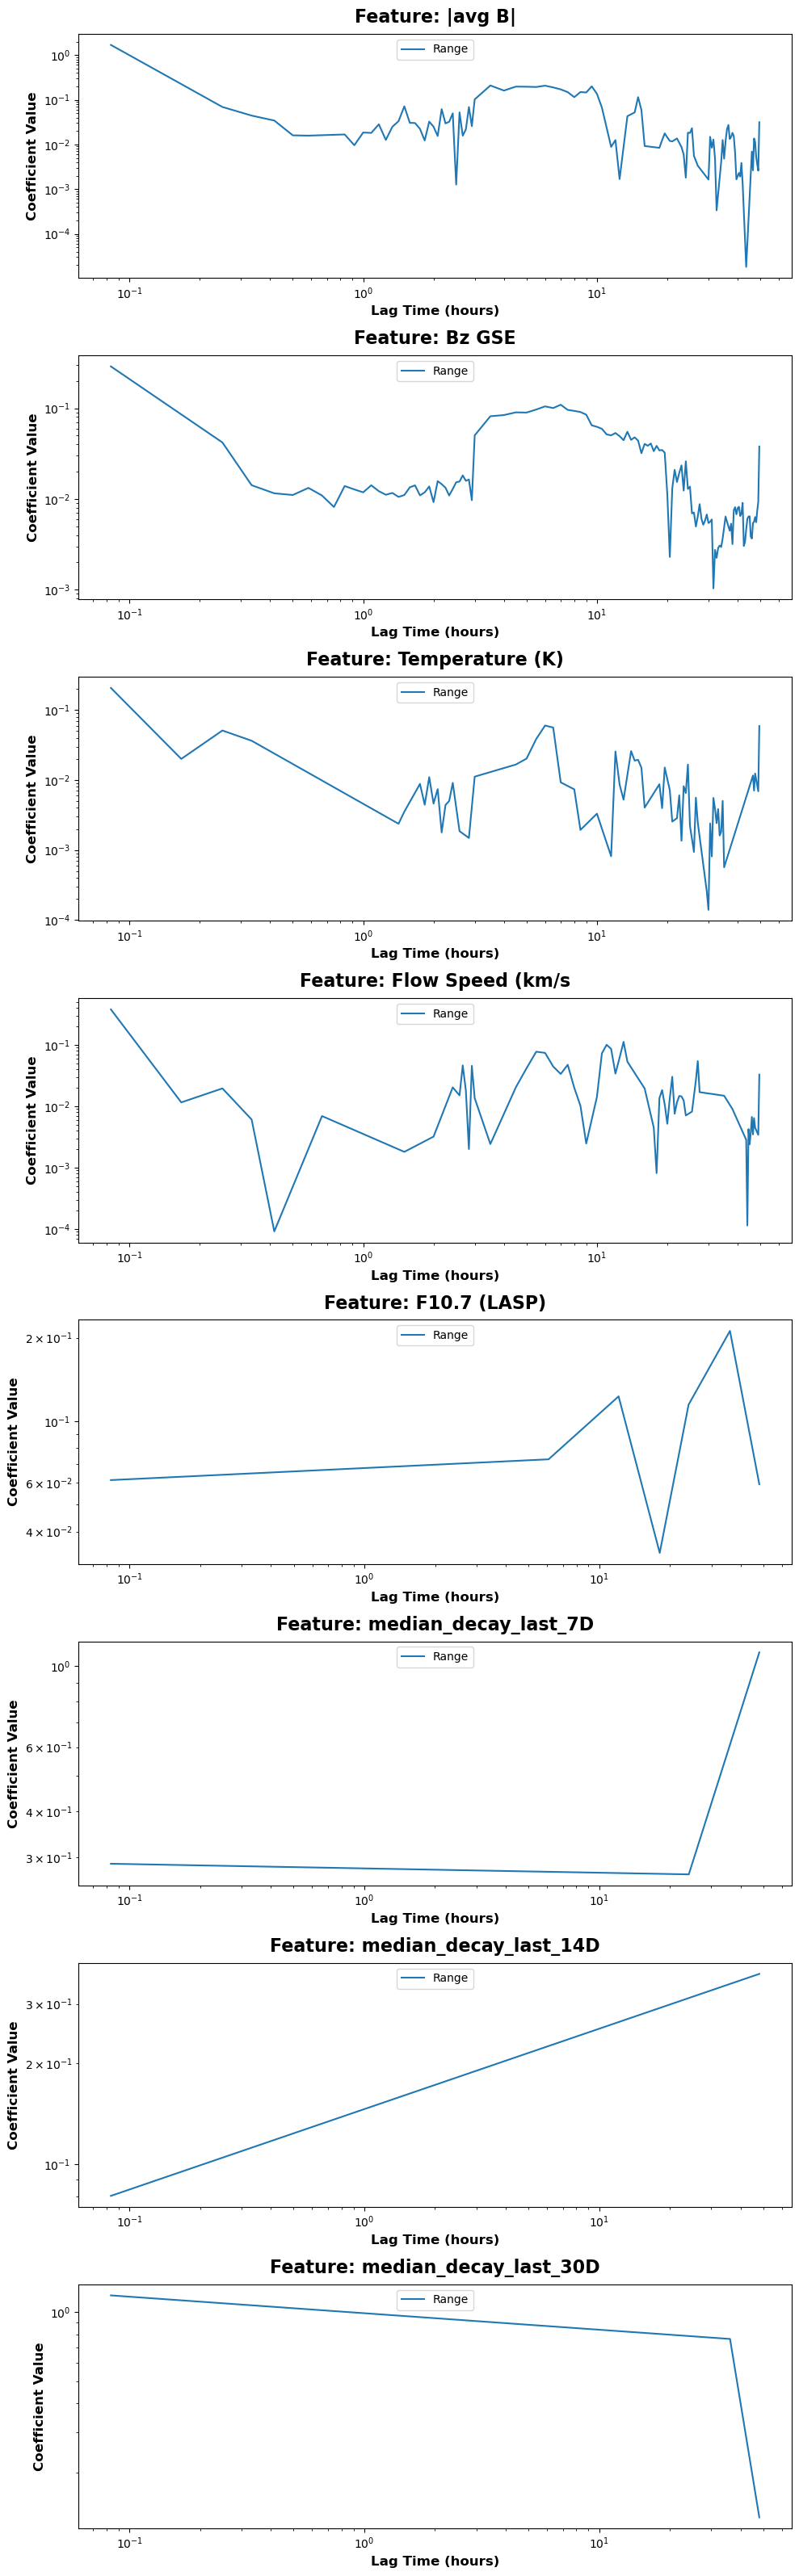

In [13]:
fig, axs = plt.subplots(len(unique_features), 1, figsize=(10, 4 * len(unique_features)))
for i, feature in enumerate(unique_features):
    ax = axs[i] if len(unique_features) > 1 else axs
    feature_coefs = coef_df[coef_df['feature'] == feature]
    
    # only include coefficients where mean is bigger than 1e-3
    feature_coefs = feature_coefs[feature_coefs['coefficient_mean'].abs() > 1e-6]

    ax.plot(
        feature_coefs['lag_time'],
        feature_coefs['coefficient_range'],
        color='tab:blue',
        ms=4,
        alpha = 1.0,
        label="Range"
    )
    
    ax.set_title(f'Feature: {feature}')
    ax.set_xlabel('Lag Time (hours)')
    ax.set_ylabel('Coefficient Value')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='upper center', ncol = 2)
# plot legend outside of plots
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=3)
# plt.xlabel('Lag Time (hours)')
plt.tight_layout()
plt.show()

# 2. Check Lag Features

In [14]:
# Summary of active lags
active_lags = np.sum(np.any(coeff_all != 0, axis=0))
total_lags = coeff_all.shape[1]
print(f"Active Lags: {active_lags:3d}/{total_lags} ({(active_lags/total_lags)*100:.2f}%)")

for feature in unique_features:
    print(f"    {feature}:")
    coef_feature = coef_df[coef_df['feature'] == feature]
    active_lags = coef_feature[coef_feature['coefficient_mean'].abs() > 0]
    all_pos = (active_lags['coefficient_min'] > 0).sum()
    all_neg = (active_lags['coefficient_max'] < 0).sum()
    pos_neg = ((active_lags['coefficient_0'] > 0) & (active_lags['coefficient_n'] < 0)).sum()
    neg_pos = ((active_lags['coefficient_0'] < 0) & (active_lags['coefficient_n'] > 0)).sum()
    rest = active_lags.shape[0] - all_pos - all_neg - pos_neg - neg_pos
    print(f"       {active_lags.shape[0]} lags ({active_lags.shape[0]/coef_feature.shape[0]*100:.1f}%)")
    print(f"       {all_pos} ++, {all_neg} --, {pos_neg} +-, {neg_pos} -+, {rest} rest")

Active Lags: 379/538 (70.45%)
    |avg B|:
       103 lags (79.8%)
       31 ++, 49 --, 23 +-, 0 -+, 0 rest
    Bz GSE:
       127 lags (98.4%)
       52 ++, 51 --, 0 +-, 24 -+, 0 rest
    Temperature (K):
       68 lags (52.7%)
       13 ++, 22 --, 26 +-, 5 -+, 2 rest
    Flow Speed (km/s:
       66 lags (51.2%)
       10 ++, 31 --, 25 +-, 0 -+, 0 rest
    F10.7 (LASP):
       7 lags (100.0%)
       5 ++, 1 --, 0 +-, 1 -+, 0 rest
    median_decay_last_7D:
       3 lags (60.0%)
       1 ++, 2 --, 0 +-, 0 -+, 0 rest
    median_decay_last_14D:
       2 lags (40.0%)
       1 ++, 1 --, 0 +-, 0 -+, 0 rest
    median_decay_last_30D:
       3 lags (60.0%)
       1 ++, 2 --, 0 +-, 0 -+, 0 rest


Plot Active and Inactive Coefficients

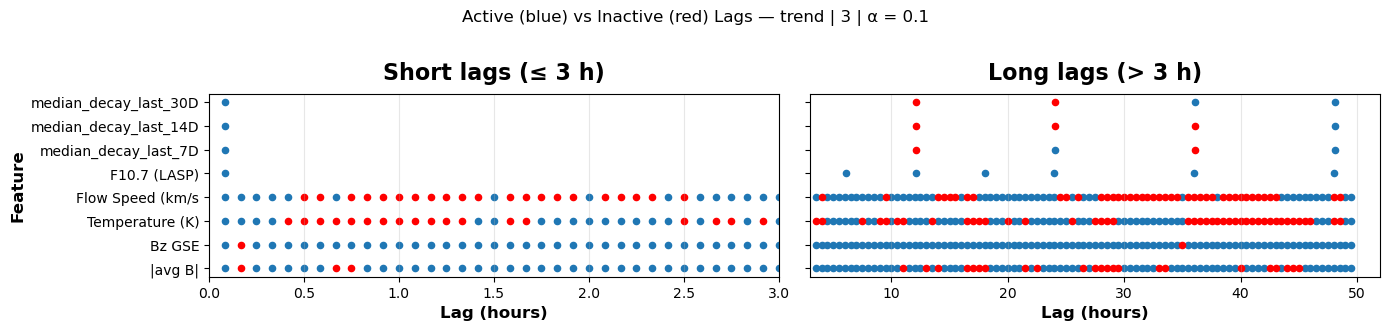

In [15]:
# masks
active_mask = np.any(coeff_all != 0, axis=0)
inactive_mask = np.all(coeff_all == 0, axis=0)

active_lag_names = X_test.columns[active_mask]
inactive_lag_names = X_test.columns[inactive_mask]

# --- build dataframes ---
df_active = (
    active_lag_names
    .to_series(name="coef")
    .str.extract(r'^(?P<feature>.+?)_lag_(?P<lag>\d+)$')
    .assign(lag=lambda d: d["lag"].astype(int))
)

df_inactive = (
    inactive_lag_names
    .to_series(name="coef")
    .str.extract(r'^(?P<feature>.+?)_lag_(?P<lag>\d+)$')
    .assign(lag=lambda d: d["lag"].astype(int))
)

# combine feature order from both
feature_order = pd.concat([df_active["feature"], df_inactive["feature"]]).unique()
feature_to_y = {f: i for i, f in enumerate(feature_order)}

# map y
df_active["y"] = df_active["feature"].map(feature_to_y)
df_inactive["y"] = df_inactive["feature"].map(feature_to_y)

# convert to hours (5 min resolution)
df_active["hours"] = df_active["lag"] * 5 / 60
df_inactive["hours"] = df_inactive["lag"] * 5 / 60

# split
h_split = 3

mask_short_a = df_active["hours"] <= h_split
mask_long_a  = df_active["hours"] > h_split

mask_short_i = df_inactive["hours"] <= h_split
mask_long_i  = df_inactive["hours"] > h_split

# --- plotting ---
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    sharey=True,
    figsize=(14, 0.4 * len(feature_order)),
    gridspec_kw={"width_ratios": [1, 1]}
)

# LEFT panel
ax1.scatter(df_active.loc[mask_short_a, "hours"],
            df_active.loc[mask_short_a, "y"],
            s=20)

ax1.scatter(df_inactive.loc[mask_short_i, "hours"],
            df_inactive.loc[mask_short_i, "y"],
            s=20,
            color="red")

ax1.set_xlim(0, h_split)
ax1.set_xlabel("Lag (hours)")
ax1.set_title("Short lags (≤ 3 h)")
ax1.grid(axis="x", alpha=0.3)

# RIGHT panel
ax2.scatter(df_active.loc[mask_long_a, "hours"],
            df_active.loc[mask_long_a, "y"],
            s=20)

ax2.scatter(df_inactive.loc[mask_long_i, "hours"],
            df_inactive.loc[mask_long_i, "y"],
            s=20,
            color="red")

ax2.set_xlim(h_split, max(df_active["hours"].max(),
                          df_inactive["hours"].max()) * 1.05)
ax2.set_xlabel("Lag (hours)")
ax2.set_title("Long lags (> 3 h)")
ax2.grid(axis="x", alpha=0.3)

# y-axis
ax1.set_yticks(range(len(feature_order)))
ax1.set_yticklabels(feature_order)
ax1.set_ylabel("Feature")

fig.suptitle(f"Active (blue) vs Inactive (red) Lags — {target} | {number} | α = {Alpha}", y=1.02)

plt.tight_layout()
plt.show()